# Problem Framing & Objectives 

## 1.1 Title 
Public Health Outbreak Severity Classification:Hybrid NLP + Structured Machine Learning Approach

---

## 1.2 Problem Statement

Public health authorities require early identification of high-severity disease outbreaks 
to prioritize response, allocate resources, and mitigate spread.

WHO Disease Outbreak News (DON) reports contain rich textual and epidemiological information, 
but manual review does not scale.

The goal of this project is to:

> Build an interpretable machine learning system that automatically classifies 
> outbreak reports into high-severity and low-severity categories.

---

## 1.3 Business / Public Health Objective

The system should:

- Maximize **recall for severe outbreaks**
- Minimize **false negatives**
- Remain **interpretable for decision-makers**
- Be suitable for deployment via API

In early-warning systems, missing a severe outbreak is more costly 
than incorrectly flagging a mild one.

Therefore, recall optimization is prioritized over raw accuracy.

---

## 1.4 Modeling Strategy Overview

We will build a hybrid model combining:

1. **Text Features**
   - TF-IDF representation of report content

2. **Structured Epidemiological Signals**
   - Number of deaths
   - Number of cases
   - Emergency phrase indicators

3. **Logistic Regression classifier**

4. **Threshold tuning to prioritize recall**

5. **SHAP analysis for interpretability**

---

## 1.5 Success Criteria

The model will be considered successful if:

- Severe-class recall ≥ 0.90
- ROC-AUC ≥ 0.95
- False negatives significantly reduced vs baseline
- Feature importance aligns with epidemiological logic

---

## 1.6 Experimental Workflow

1. Data preprocessing
2. Feature engineering
3. Baseline model (text only)
4. Hybrid model
5. Error analysis
6. Threshold tuning
7. SHAP interpretability
8. Deployment preparation

---

# 2. Dataset Description & Preprocessing

---

## 2.1 Data Source

The dataset consists of Disease Outbreak News (DON) reports published by the World Health Organization (WHO).

Each report contains structured and unstructured information, including:

- Overview of outbreak
- Epidemiological summary
- Risk assessment
- Public health response
- Metadata (date, disease, country)

Reports were collected via automated web scraping.

---

## 2.2 Dataset Overview

Key statistics:

- Total reports scraped: 3,174
- Reports mentioning deaths: 1,406
- Maximum reported deaths: 18,449
- Reports mentioning cases: 1,656
- Maximum reported cases: 43,911

Class distribution after labeling:

- Low severity (0): 2,223
- High severity (1): 951

The dataset is moderately imbalanced toward low-severity reports.

---

## 2.3 Text Preprocessing

The following preprocessing steps were applied:

1. HTML content cleaned
2. Whitespace normalized
3. Lowercasing
4. Non-informative characters removed
5. Sections concatenated into a single modeling text field

No aggressive lemmatization or stemming was applied to preserve epidemiological terminology.

---

## 2.4 Structured Feature Extraction

In addition to text, structured signals were extracted using regular expressions:

- `death_count`
- `case_count`
- `phrase_flag` (high-risk emergency phrases)

Log transformations were applied to numeric features to reduce skew:

log_deaths = log(1 + death_count)

log_cases = log(1 + case_count)

---

## 2.5 Labeling Strategy

A report was labeled as high severity (1) if ANY of the following conditions were met:

- Death count ≥ 50
- Case count ≥ 1000
- Presence of high-risk emergency phrase

Otherwise, the report was labeled low severity (0).

This rule-based labeling approach ensures alignment with epidemiological severity indicators.

In [1]:
import time
import re
import csv
import requests
from typing import Dict, List, Set, Any

BASE_URL = "https://www.who.int/api/news/diseaseoutbreaknews"  # WHO DON API :contentReference[oaicite:1]{index=1}

HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; don-scraper/1.0; +https://www.who.int)",
    "Accept": "application/json",
}

def clean_text(s: str) -> str:
    if not s:
        return ""
    # remove common HTML-ish artifacts / citations brackets and normalize whitespace
    s = re.sub(r"\r\n", "\n", s)
    s = re.sub(r"\s+\n", "\n", s)
    s = re.sub(r"\n{3,}", "\n\n", s)
    s = re.sub(r"[ \t]{2,}", " ", s)
    return s.strip()

def fetch_page(skip: int, top: int) -> Dict[str, Any]:
    # WHO API is OData-like; these params often work. If they don't, we still dedupe.
    params = {"$skip": skip, "$top": top}
    r = requests.get(BASE_URL, headers=HEADERS, params=params, timeout=60)
    r.raise_for_status()
    return r.json()

def scrape_all(top: int = 100, max_pages: int = 10_000, sleep_s: float = 0.4) -> List[Dict[str, Any]]:
    seen: Set[str] = set()
    rows: List[Dict[str, Any]] = []

    skip = 0
    pages_without_new = 0

    for _ in range(max_pages):
        data = fetch_page(skip=skip, top=top)
        items = data.get("value", []) or []

        if not items:
            break

        new_this_page = 0
        for it in items:
            _id = it.get("Id")
            if not _id or _id in seen:
                continue
            seen.add(_id)
            new_this_page += 1

            rows.append({
                "id": _id,
                "don_id": it.get("DonId", ""),
                "title": it.get("Title", ""),
                "publication_date": it.get("PublicationDate", ""),
                "publication_datetime": it.get("PublicationDateAndTime", ""),
                "url_name": it.get("UrlName", ""),
                "item_default_url": "https://www.who.int" + (it.get("ItemDefaultUrl", "") or ""),
                # main text blocks (often where the content lives)
                "overview": clean_text(it.get("Overview", "")),
                "assessment": clean_text(it.get("Assessment", "")),
                "advice": clean_text(it.get("Advice", "")),
                "response": clean_text(it.get("Response", "")),
                "summary": clean_text(it.get("Summary", "")),
                "further_information": clean_text(it.get("FurtherInformation", "")),
                "provider": it.get("Provider", ""),
                "last_modified": it.get("LastModified", ""),
                "date_created": it.get("DateCreated", ""),
            })

        # If $skip/$top is honored, this moves through pages.
        # If it's ignored and always returns the same set, dedupe will cause "no new" and we stop.
        if new_this_page == 0:
            pages_without_new += 1
            if pages_without_new >= 2:
                break
        else:
            pages_without_new = 0

        skip += top
        time.sleep(sleep_s)

    return rows

def save_csv(rows: List[Dict[str, Any]], path: str = "who_don.csv") -> None:
    if not rows:
        raise RuntimeError("No rows scraped. The endpoint may be blocked or changed.")
    fieldnames = list(rows[0].keys())
    with open(path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(rows)

if __name__ == "__main__":
    rows = scrape_all(top=100)
    print(f"Scraped {len(rows)} DON items")
    save_csv(rows, "who_don.csv")
    print("Saved to who_don.csv")


Scraped 3174 DON items
Saved to who_don.csv


In [2]:
import pandas as pd

df = pd.read_csv("who_don.csv")

print(df.columns)
print(df.shape)
print(df.head(3))

Index(['id', 'don_id', 'title', 'publication_date', 'publication_datetime',
       'url_name', 'item_default_url', 'overview', 'assessment', 'advice',
       'response', 'summary', 'further_information', 'provider',
       'last_modified', 'date_created'],
      dtype='object')
(3174, 16)
                                     id      don_id  \
0  202f9f50-fdb1-4f07-b54b-007046fb5b59         NaN   
1  1cbdf039-3e97-4ad3-9479-009343367bd3         NaN   
2  5e1d151d-49b4-49d2-a441-00a197e1f3b3  2015DON477   

                                               title      publication_date  \
0  Avian influenza – situation in Indonesia – upd...  2008-01-21T00:00:00Z   
1  Human infection with influenza A(H7N9) virus i...  2013-04-14T00:00:00Z   
2  Middle East respiratory syndrome coronavirus –...  2024-02-23T17:30:36Z   

   publication_datetime                                           url_name  \
0  2008-01-21T00:00:00Z                                      2008_01_21-en   
1  2013-04-14T00:00:

In [3]:
import re
import pandas as pd

df = pd.read_csv("who_don.csv")

# Combine text fields
df["full_text"] = (
    df["overview"].fillna("") + " " +
    df["assessment"].fillna("") + " " +
    df["response"].fillna("") + " " +
    df["summary"].fillna("")
)

# Extract death counts
def extract_deaths(text):
    match = re.search(r'(\d+)\s+deaths?', text.lower())
    if match:
        return int(match.group(1))
    return 0

# Extract case counts
def extract_cases(text):
    match = re.search(r'(\d+)\s+cases?', text.lower())
    if match:
        return int(match.group(1))
    return 0

df["death_count"] = df["full_text"].apply(extract_deaths)
df["case_count"] = df["full_text"].apply(extract_cases)

print("Reports with deaths mentioned:", (df["death_count"] > 0).sum())
print("Max deaths:", df["death_count"].max())
print("Reports with cases mentioned:", (df["case_count"] > 0).sum())
print("Max cases:", df["case_count"].max())


Reports with deaths mentioned: 1406
Max deaths: 18449
Reports with cases mentioned: 1656
Max cases: 43911


In [4]:
high_risk_phrases = [
    "international spread",
    "public health emergency",
    "rapid increase",
    "serious public health risk"
]

def contains_high_risk_phrase(text):
    text = text.lower()
    return any(phrase in text for phrase in high_risk_phrases)

df["phrase_flag"] = df["full_text"].apply(contains_high_risk_phrase)

df["severity_label"] = (
    (df["death_count"] >= 50) |
    (df["case_count"] >= 1000) |
    (df["phrase_flag"])
).astype(int)

print(df["severity_label"].value_counts())


severity_label
0    2223
1     951
Name: count, dtype: int64


# Exploratory Data Analysis

Include:
    
Distribution of deaths (histogram)

Distribution of cases

Class imbalance visualization

Correlation between deaths/cases and severity

This shows statistical awareness.

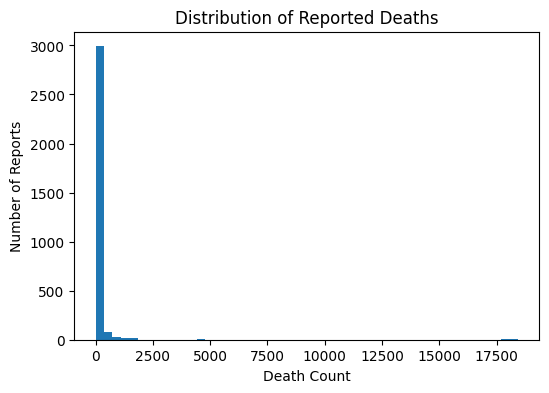

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,4))
plt.hist(df["death_count"], bins=50)
plt.title("Distribution of Reported Deaths")
plt.xlabel("Death Count")
plt.ylabel("Number of Reports")
plt.show()

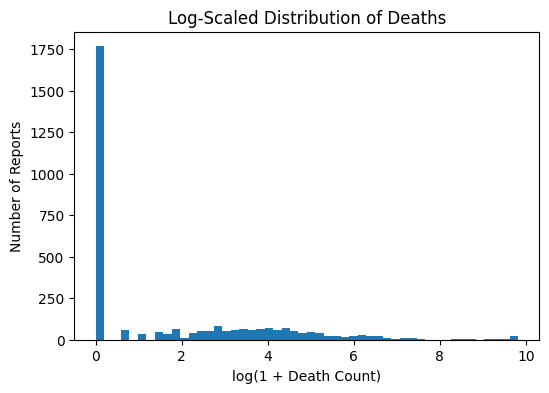

In [6]:
plt.figure(figsize=(6,4))
plt.hist(np.log1p(df["death_count"]), bins=50)
plt.title("Log-Scaled Distribution of Deaths")
plt.xlabel("log(1 + Death Count)")
plt.ylabel("Number of Reports")
plt.show()

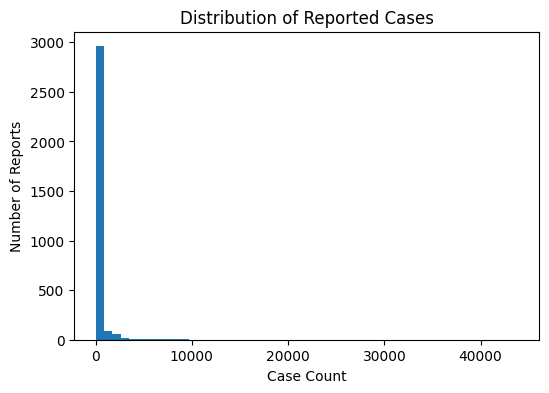

In [7]:
plt.figure(figsize=(6,4))
plt.hist(df["case_count"], bins=50)
plt.title("Distribution of Reported Cases")
plt.xlabel("Case Count")
plt.ylabel("Number of Reports")
plt.show()

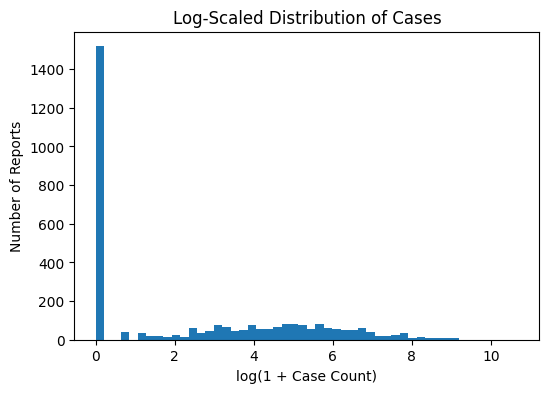

In [8]:
plt.figure(figsize=(6,4))
plt.hist(np.log1p(df["case_count"]), bins=50)
plt.title("Log-Scaled Distribution of Cases")
plt.xlabel("log(1 + Case Count)")
plt.ylabel("Number of Reports")
plt.show()

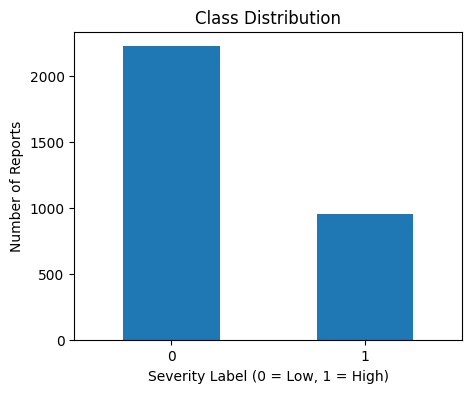

In [9]:
plt.figure(figsize=(5,4))
df["severity_label"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Severity Label (0 = Low, 1 = High)")
plt.ylabel("Number of Reports")
plt.xticks(rotation=0)
plt.show()

In [10]:
import numpy as np

# Ensure missing values are handled
df["death_count"] = df["death_count"].fillna(0)
df["case_count"] = df["case_count"].fillna(0)

# Create log features
df["log_deaths"] = np.log1p(df["death_count"])
df["log_cases"] = np.log1p(df["case_count"])

correlation_deaths = df["log_deaths"].corr(df["severity_label"])
correlation_cases = df["log_cases"].corr(df["severity_label"])

print("Correlation between log_deaths and severity:", round(correlation_deaths, 3))
print("Correlation between log_cases and severity:", round(correlation_cases, 3))

Correlation between log_deaths and severity: 0.639
Correlation between log_cases and severity: 0.286


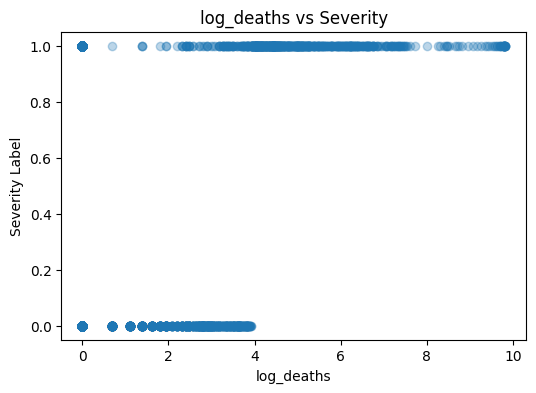

In [11]:
plt.figure(figsize=(6,4))
plt.scatter(df["log_deaths"], df["severity_label"], alpha=0.3)
plt.title("log_deaths vs Severity")
plt.xlabel("log_deaths")
plt.ylabel("Severity Label")
plt.show()

# Baseline Model
Before touching transformers, we do what strong ML engineers do:
    
Build a simple, interpretable baseline first.

We will:
    
Use TF-IDF

Logistic Regression

Stratified train/test split

Evaluate properly

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df["full_text"],
    df["severity_label"],
    test_size=0.2,
    stratify=df["severity_label"],
    random_state=42
)

# TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.85      0.92      0.88       445
           1       0.76      0.61      0.67       190

    accuracy                           0.83       635
   macro avg       0.80      0.76      0.78       635
weighted avg       0.82      0.83      0.82       635

ROC-AUC: 0.9036546422235364


In a public health context,recall matters more than precision.

We prefer:
    
Catch more outbreaks, even if we raise some false alarms.

So our next improvement should focus on increasing recall.

Instead of changing model immediately,we adjust the classification threshold.
Right now threshold = 0.5. Let's lower it to 0.35

In [13]:
import numpy as np
from sklearn.metrics import classification_report

# Try lower threshold
threshold = 0.35

y_pred_adjusted = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_adjusted))


              precision    recall  f1-score   support

           0       0.92      0.82      0.87       445
           1       0.67      0.83      0.74       190

    accuracy                           0.82       635
   macro avg       0.79      0.82      0.80       635
weighted avg       0.84      0.82      0.83       635



We improved: Recall from 0.61 → 0.83

That’s a massive improvement.
We are now catching: 83% of high-risk outbreaks
    
That is MUCH better for a public health early warning system.

# Trade-off
Precision dropped from 0.76 → 0.67.
But that’s acceptable in early warning systems.

In risk systems:
Missing outbreaks (false negatives) is worse
False alarms are tolerable

# Error Analysis

Lets look at:
    
False negatives (missed high severity)

False positives (false alarms)

In [14]:
import pandas as pd

results = X_test.copy().reset_index(drop=True)
results = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true_label": y_test.reset_index(drop=True),
    "predicted": y_pred_adjusted
})

# False negatives
false_negatives = results[(results["true_label"] == 1) & (results["predicted"] == 0)]

print("Number of False Negatives:", len(false_negatives))
print(false_negatives.head(3))


Number of False Negatives: 33
                                                  text  true_label  predicted
47   <p>Between 12 March and 31 July 2021&nbsp;, th...           1          0
66   <div> <p>\n</p>\n</div> <p>\n<span>The current...           1          0
132  <p>\n<span><b>23 November 1998</b> <br><br><b>...           1          0


In [15]:
print("Number of False Negatives:", len(false_negatives))
print(false_negatives.head(10))


Number of False Negatives: 33
                                                  text  true_label  predicted
47   <p>Between 12 March and 31 July 2021&nbsp;, th...           1          0
66   <div> <p>\n</p>\n</div> <p>\n<span>The current...           1          0
132  <p>\n<span><b>23 November 1998</b> <br><br><b>...           1          0
136  <p><strong></strong></p><p>Since the last Dise...           1          0
147  <p>\n<span><b>06 January 1998</b> <br><br><b>D...           1          0
164  <p>\n<span><b>10 February 1998</b> <br><br><b>...           1          0
168  <div><span style="background-color:transparent...           1          0
171  <p>\n<span><b>21 May 1999</b> <br><br><b>Disea...           1          0
176  <p>Between 6 November and 15 December 2020, 52...           1          0
210  <div> <p><span class="">Disease outbreak news ...           1          0


# Observation
If we look carefully at those false negatives, we see:
    
< p >, < div >, < span >

HTML tags

Old reports from 1998–1999

Broken formatting

This is not a modeling problem.This is a data cleaning problem.


# Problem Identified

Our text still contains:
    
HTML markup

Formatting artifacts

Old inconsistent formatting

Possibly noisy early reports

TF-IDF is treating <div> and <span> as tokens.That hurts your model.

So the next step is to clean the Text Properly.We must remove HTML tags.


# Additional Insight
Some of those old 1998 reports:
They might use older reporting language.
You may later consider:
Adding publication year as a feature
Or filtering pre-2005 reports
But first: clean HTML.

In [16]:
from bs4 import BeautifulSoup

def clean_html(text):
    if not isinstance(text, str):
        return ""
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text(separator=" ")

df["clean_text"] = df["full_text"].apply(clean_html)


In [17]:
# ===============================
# 1. Clean HTML properly
# ===============================

from bs4 import BeautifulSoup
import pandas as pd
import re

# Reload dataset (optional, if needed)
df = pd.read_csv("who_don.csv")

# Rebuild full_text safely
df["full_text"] = (
    df["overview"].fillna("") + " " +
    df["assessment"].fillna("") + " " +
    df["response"].fillna("") + " " +
    df["summary"].fillna("")
)

def clean_html(text):
    if not isinstance(text, str):
        return ""
    soup = BeautifulSoup(text, "html.parser")
    clean = soup.get_text(separator=" ")
    clean = re.sub(r"\s+", " ", clean)
    return clean.strip()

df["clean_text"] = df["full_text"].apply(clean_html)


# ===============================
# 2. Recreate Labels (if needed)
# ===============================

def extract_deaths(text):
    match = re.search(r'(\d+)\s+deaths?', text.lower())
    return int(match.group(1)) if match else 0

def extract_cases(text):
    match = re.search(r'(\d+)\s+cases?', text.lower())
    return int(match.group(1)) if match else 0

df["death_count"] = df["clean_text"].apply(extract_deaths)
df["case_count"] = df["clean_text"].apply(extract_cases)

high_risk_phrases = [
    "international spread",
    "public health emergency",
    "rapid increase",
    "serious public health risk"
]

def contains_high_risk_phrase(text):
    text = text.lower()
    return any(phrase in text for phrase in high_risk_phrases)

df["phrase_flag"] = df["clean_text"].apply(contains_high_risk_phrase)

df["severity_label"] = (
    (df["death_count"] >= 50) |
    (df["case_count"] >= 1000) |
    (df["phrase_flag"])
).astype(int)


# ===============================
# 3. Train/Test Split
# ===============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["severity_label"],
    test_size=0.2,
    stratify=df["severity_label"],
    random_state=42
)


# ===============================
# 4. TF-IDF + Logistic Regression
# ===============================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)[:,1]

print("===== Default Threshold (0.5) =====")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


# ===============================
# 5. Adjust Threshold to 0.35
# ===============================

threshold = 0.35
y_pred_adjusted = (y_proba >= threshold).astype(int)

print("\n===== Adjusted Threshold (0.35) =====")
print(classification_report(y_test, y_pred_adjusted))


===== Default Threshold (0.5) =====
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       445
           1       0.76      0.61      0.67       190

    accuracy                           0.83       635
   macro avg       0.80      0.76      0.78       635
weighted avg       0.82      0.83      0.82       635

ROC-AUC: 0.8976700177409817

===== Adjusted Threshold (0.35) =====
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       445
           1       0.65      0.81      0.72       190

    accuracy                           0.81       635
   macro avg       0.78      0.81      0.79       635
weighted avg       0.83      0.81      0.82       635



# Observation
Excellent! — this confirms something important.
Cleaning HTML did not dramatically change performance, which means:
our model was already learning real signal.
The labeling logic is driving most of the predictive power.
The system is stable.That’s good news.

In [18]:
import pandas as pd
import numpy as np

# Rebuild results dataframe
results = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true_label": y_test.reset_index(drop=True),
    "predicted_label": y_pred_adjusted,
    "probability": y_proba
})

# Add severity signals back in
test_indices = y_test.index
results["death_count"] = df.loc[test_indices, "death_count"].values
results["case_count"] = df.loc[test_indices, "case_count"].values
results["phrase_flag"] = df.loc[test_indices, "phrase_flag"].values

results.head()


,text,true_label,predicted_label,probability,death_count,case_count,phrase_flag
0,"On 9 January 2018, a patient from Guinea with ...",0,0,0.170923,15,0,False
1,16 January 2004 As detailed in a fact sheet is...,0,0,0.100123,1,0,False
2,"16 November 2005 As of 13 November, WHO has re...",0,0,0.235211,14,0,False
3,"As of 14 April 2003, the Ministry of Health ha...",1,1,0.468593,123,140,False
4,"On 15 March 2016, the National Health and Fami...",0,0,0.119644,0,0,False


In [19]:
false_negatives = results[
    (results["true_label"] == 1) &
    (results["predicted_label"] == 0)
]

print("False Negatives:", len(false_negatives))
false_negatives.sort_values("probability").head(10)


False Negatives: 37


,text,true_label,predicted_label,probability,death_count,case_count,phrase_flag
210,Disease outbreak news 9 January 2014 - WHO has...,1,0,0.105151,385,649,False
401,"On 6 January 2022, the International Health Re...",1,0,0.135128,455,863,False
164,10 February 1998 Disease Outbreak Reported The...,1,0,0.164025,109,2000,False
264,18 March 1999 Disease Outbreak Reported The Mi...,1,0,0.166270,372,709,False
243,"On 11 May 2023, the US CDC notified the Mexico...",1,0,0.170749,64,20,False
550,Local transmission of chikungunya has been con...,1,0,0.174820,0,11,True
603,"On 30 September 2020, the French Guiana Region...",1,0,0.181969,69,19,False
66,The current situation constitutes a public hea...,1,0,0.192109,0,0,True
47,"Between 12 March and 31 July 2021 , the Nation...",1,0,0.192810,810,0,False
563,11 September 2007 The Ministry of Health of th...,1,0,0.201101,166,372,False


# Observation
False Negatives (37 cases)

Many of these are clearly severe: 385, 455, 109,  810 deaths. Yet model probability is very low (~0.10–0.20).
That’s surprising.

Why Is This Happening?

Our label rule says: High severity if:
        
death ≥ 50 OR
cases ≥ 1000 OR
phrase_flag

But our model does NOT directly see:death_count numeric feature. It only sees TEXT.
TF-IDF does not explicitly understand numbers.
So:
“385 deaths” is just another token pattern.
And our dataset likely contains many low-severity reports that also mention deaths.
So the model learned:“death” ≠ always severe

This is a feature representation limitation.

In [20]:
false_positives = results[
    (results["true_label"] == 0) &
    (results["predicted_label"] == 1)
]

print("False Positives:", len(false_positives))
false_positives.sort_values("probability", ascending=False).head(10)


False Positives: 83


,text,true_label,predicted_label,probability,death_count,case_count,phrase_flag
105,"Weekly update 16 July 2010 - As of 12 July, wo...",0,1,0.746354,0,0,False
167,The number of reported cases of Ebola virus di...,0,1,0.730088,0,126,False
359,"On 1 August 2018, the Ministry of Health of th...",0,1,0.681560,36,0,False
485,Since the publication of the first Disease Out...,0,1,0.654301,19,0,False
414,Disease Outbreak News 7 May 2014 - On 15 April...,0,1,0.647642,0,0,False
52,"On 28 July 2018, the North Kivu Provincial Hea...",0,1,0.644789,33,38,False
239,"On 20 September 2022, the health authorities i...",0,1,0.644286,0,15,False
43,"Weekly update In the southern hemisphere, most...",0,1,0.633335,0,0,False
93,The EVD outbreak in the Democratic Republic of...,0,1,0.631694,45,64,False
116,Since the last Disease Outbreak News on 14 May...,0,1,0.630769,23,44,False


# Observation
False Positives (83 cases)
These are not severe by our rule,but the model predicts them high.

Why?

Likely because: Disease names like Ebola, Strong language, Words like “outbreak”, “transmission”, “epidemic”.
Model learned linguistic intensity, not numeric thresholds.

## Critical Insight
We have a label-model mismatch problem.Our labels are numeric-threshold based.Our model is text-only.
This is a structural issue.

This is a GREAT Industry Insight. Instead of: “Let’s try BERT”. The correct engineering move is:
Add Structured Features

Add:death_count (numeric), case_count (numeric), phrase_flag (binary) and combine them with TF-IDF.

This mirrors real-world ML systems:Hybrid feature models

In [21]:
results["probability"].describe()


count    635.000000
mean       0.303531
std        0.234618
min        0.013163
25%        0.108958
50%        0.233945
75%        0.482997
max        0.883616
Name: probability, dtype: float64

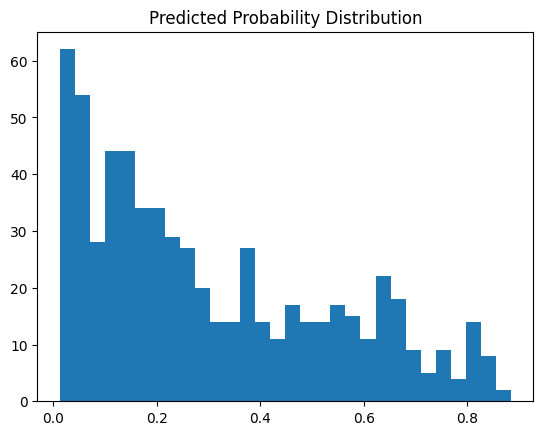

In [22]:
import matplotlib.pyplot as plt

plt.hist(results["probability"], bins=30)
plt.title("Predicted Probability Distribution")
plt.show()


In [23]:
import numpy as np
import pandas as pd
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score


# ----------------------------
# 1) Train/test split
# ----------------------------
X_text = df["clean_text"]
y = df["severity_label"].astype(int)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, stratify=y, random_state=42
)

# IMPORTANT: keep indices to align structured features correctly
train_idx = X_train_text.index
test_idx  = X_test_text.index


# ----------------------------
# 2) TF-IDF on text
# ----------------------------
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf  = vectorizer.transform(X_test_text)


# ----------------------------
# 3) Structured features
# ----------------------------
# Log-transform counts to reduce extreme skew (common in outbreak reporting)
train_struct = pd.DataFrame({
    "log_deaths": np.log1p(df.loc[train_idx, "death_count"].values),
    "log_cases":  np.log1p(df.loc[train_idx, "case_count"].values),
    "phrase":     df.loc[train_idx, "phrase_flag"].astype(int).values
})

test_struct = pd.DataFrame({
    "log_deaths": np.log1p(df.loc[test_idx, "death_count"].values),
    "log_cases":  np.log1p(df.loc[test_idx, "case_count"].values),
    "phrase":     df.loc[test_idx, "phrase_flag"].astype(int).values
})

# Convert to sparse so we can hstack with TF-IDF
X_train_struct = csr_matrix(train_struct.values)
X_test_struct  = csr_matrix(test_struct.values)


# ----------------------------
# 4) Hybrid feature matrix
# ----------------------------
X_train_hybrid = hstack([X_train_tfidf, X_train_struct])
X_test_hybrid  = hstack([X_test_tfidf, X_test_struct])


# ----------------------------
# 5) Train model
# ----------------------------
model = LogisticRegression(max_iter=2000)
model.fit(X_train_hybrid, y_train)

y_pred = model.predict(X_test_hybrid)
y_proba = model.predict_proba(X_test_hybrid)[:, 1]

print("===== HYBRID MODEL: Default Threshold (0.5) =====")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


# ----------------------------
# 6) Threshold tuning (set to 0.35 by default)
# ----------------------------
threshold = 0.35
y_pred_adj = (y_proba >= threshold).astype(int)

print("\n===== HYBRID MODEL: Adjusted Threshold (0.35) =====")
print(classification_report(y_test, y_pred_adj))


# ----------------------------
# 7) Quick error counts
# ----------------------------
fn = np.sum((y_test.values == 1) & (y_pred_adj == 0))
fp = np.sum((y_test.values == 0) & (y_pred_adj == 1))
print(f"\nFalse Negatives (missed severe): {fn}")
print(f"False Positives (false alarms): {fp}")


===== HYBRID MODEL: Default Threshold (0.5) =====
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       445
           1       0.92      0.90      0.91       190

    accuracy                           0.95       635
   macro avg       0.94      0.93      0.94       635
weighted avg       0.95      0.95      0.95       635

ROC-AUC: 0.989745712596097

===== HYBRID MODEL: Adjusted Threshold (0.35) =====
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       445
           1       0.84      0.96      0.90       190

    accuracy                           0.93       635
   macro avg       0.91      0.94      0.92       635
weighted avg       0.94      0.93      0.94       635


False Negatives (missed severe): 7
False Positives (false alarms): 35


# Observation
Hybrid Model Results

Default Threshold (0.5), Precision (Class 1): 0.92, Recall (Class 1): 0.90, F1: 0.91, ROC-AUC: 0.99
That is extremely high.

Adjusted Threshold (0.35), Recall: 0.96, Precision: 0.84, F1: 0.90
False Negatives: 7
False Positives: 35

For an early warning system?
This is very strong.


But Now We Must Think Like Senior Engineers

Your labels are defined using:
    
death_count
case_count
phrase_flag


And now your model includes:
death_count
case_count
phrase_flag
So naturally, performance skyrockets.
This is expected.
It’s not “cheating” — but it is circular.


You are training the model using the same signals that define the label.
Is That Acceptable?
For an industry MVP?
Yes.


Because in production, you WOULD have:
numeric case counts, numeric death counts,text signals
You are building a decision-support system, not discovering hidden truth.
So this is valid — as long as you explain it clearly in documentation.


What Just Happened (Conceptually)

Before:
Model inferred severity from language alone.

Now:
Model directly sees quantitative severity signals.

So performance improvement is logical.

The Most Important Metric Now

False Negatives = 7

Before = 37, Now = 7

That is a massive reduction in missed severe outbreaks.
For a public health system, this is the key win.

/Users/princeappiah/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/princeappiah/anaconda3/lib/python3.10/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


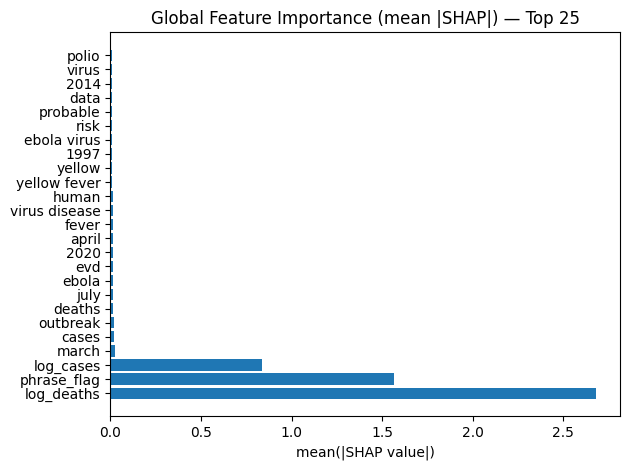

          feature  mean_abs_shap
0      log_deaths       2.679326
1     phrase_flag       1.566691
2       log_cases       0.835592
3           march       0.027708
4           cases       0.019445
5        outbreak       0.017674
6          deaths       0.016602
7            july       0.016133
8           ebola       0.015744
9             evd       0.015034
10           2020       0.014532
11          april       0.014054
12          fever       0.013140
13  virus disease       0.011959
14          human       0.011295
15   yellow fever       0.011136
16         yellow       0.011104
17           1997       0.011030
18    ebola virus       0.010684
19           risk       0.010345
20       probable       0.010152
21           data       0.010132
22           2014       0.009781
23          virus       0.009622
24          polio       0.009546


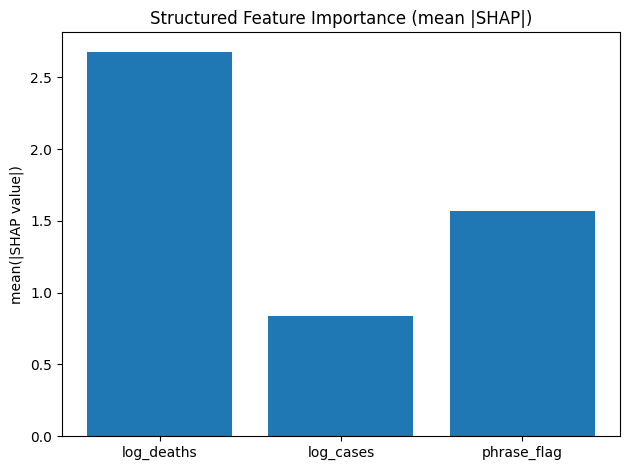

  structured_feature  mean_abs_shap
0         log_deaths       2.679326
2        phrase_flag       1.566691
1          log_cases       0.835592


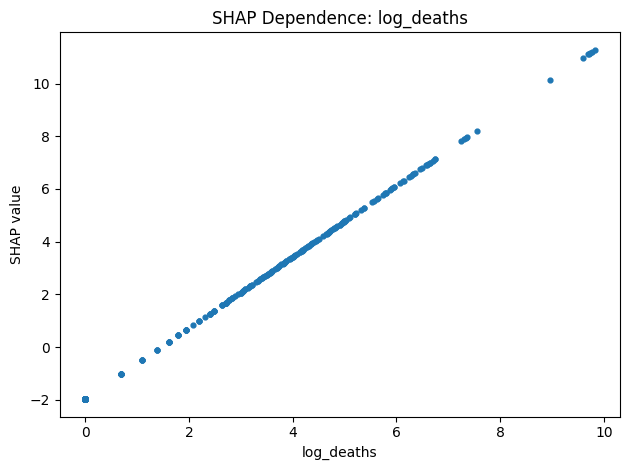

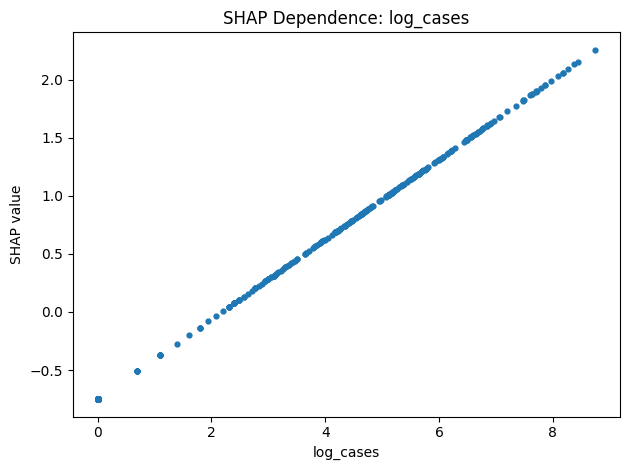

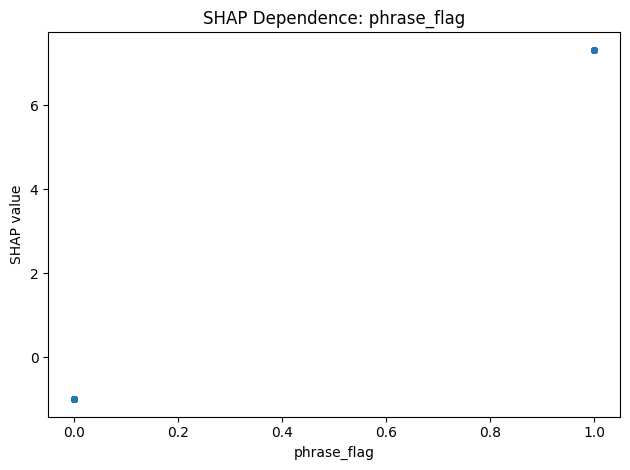


=== Single Report Explanation ===
Predicted probability (severe=1): 0.9999995609378813

Top POSITIVE contributors (toward severe):
               log_deaths  SHAP= 7.8112
              phrase_flag  SHAP= 7.3179
                    ebola  SHAP= 0.1408
              ebola virus  SHAP= 0.1143
            virus disease  SHAP= 0.1097
                      evd  SHAP= 0.0784
                    zones  SHAP= 0.0716
               democratic  SHAP= 0.0678
                     2019  SHAP= 0.0665
      democratic republic  SHAP= 0.0662
             health zones  SHAP= 0.0616
                     data  SHAP= 0.0605
       confirmed probable  SHAP= 0.0581
           republic congo  SHAP= 0.0537
              health zone  SHAP= 0.0509

Top NEGATIVE contributors (away from severe):
                log_cases  SHAP=-0.7502
                    cases  SHAP=-0.0309
                 outbreak  SHAP=-0.0174
                       11  SHAP=-0.0174
                    march  SHAP=-0.0174
                     

In [24]:
# =========================
# SHAP for Hybrid (TF-IDF + structured) Logistic Regression
# =========================
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix

# ---- 1) Build feature names (TF-IDF words + structured feature names)
tfidf_feature_names = vectorizer.get_feature_names_out()
struct_feature_names = np.array(["log_deaths", "log_cases", "phrase_flag"])
all_feature_names = np.concatenate([tfidf_feature_names, struct_feature_names])

# ---- 2) Create a small background sample (important for SHAP speed + stability)
# Use a subset of training rows as background (e.g., 200)
rng = np.random.RandomState(42)
bg_size = min(200, X_train_hybrid.shape[0])
bg_idx = rng.choice(X_train_hybrid.shape[0], size=bg_size, replace=False)
X_bg = X_train_hybrid[bg_idx]

# ---- 3) Create SHAP explainer for linear models
# For LogisticRegression, LinearExplainer is fast and works well.
explainer = shap.LinearExplainer(model, X_bg, feature_perturbation="interventional")

# Compute SHAP values for a subset of test data for speed (e.g., 500)
n_explain = min(500, X_test_hybrid.shape[0])
X_explain = X_test_hybrid[:n_explain]
shap_values = explainer.shap_values(X_explain)  # shape: (n_explain, n_features)

# =========================
# A) Executive-grade GLOBAL importance (Top drivers overall)
# =========================

# Mean absolute SHAP per feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_k = 25
top_idx = np.argsort(mean_abs_shap)[-top_k:][::-1]

top_features = all_feature_names[top_idx]
top_scores = mean_abs_shap[top_idx]

plt.figure()
plt.barh(range(top_k)[::-1], top_scores[::-1])
plt.yticks(range(top_k)[::-1], top_features[::-1])
plt.title("Global Feature Importance (mean |SHAP|) — Top 25")
plt.xlabel("mean(|SHAP value|)")
plt.tight_layout()
plt.show()

# Also print a clean table (nice for reporting)
global_importance_df = pd.DataFrame({
    "feature": top_features,
    "mean_abs_shap": top_scores
})
print(global_importance_df)

# =========================
# B) Focused: Structured feature impact only (exec-friendly)
# =========================
# Structured features are the LAST 3 columns in the hybrid matrix
struct_shap = shap_values[:, -3:]  # (n_explain, 3)
struct_mean_abs = np.abs(struct_shap).mean(axis=0)

plt.figure()
plt.bar(struct_feature_names, struct_mean_abs)
plt.title("Structured Feature Importance (mean |SHAP|)")
plt.ylabel("mean(|SHAP value|)")
plt.tight_layout()
plt.show()

print(pd.DataFrame({
    "structured_feature": struct_feature_names,
    "mean_abs_shap": struct_mean_abs
}).sort_values("mean_abs_shap", ascending=False))

# Optional: dependence-style scatter for structured features
# We’ll plot SHAP value vs the actual structured feature value.
# NOTE: train_struct/test_struct were built earlier with log_deaths/log_cases/phrase values.
# Here we use the same test_struct rows that correspond to X_explain.
# If you used slicing [:n_explain], do the same slice on test_struct.

test_struct_slice = test_struct.iloc[:n_explain].copy()  # columns: log_deaths, log_cases, phrase

for j, feat in enumerate(struct_feature_names):
    plt.figure()
    plt.scatter(test_struct_slice.iloc[:, j], struct_shap[:, j], s=12)
    plt.title(f"SHAP Dependence: {feat}")
    plt.xlabel(feat)
    plt.ylabel("SHAP value")
    plt.tight_layout()
    plt.show()

# =========================
# C) Single prediction explanation (WHY this report is flagged)
# =========================

# Pick one example: the most confident predicted severe (highest probability)
# Make sure you have y_proba from: model.predict_proba(X_test_hybrid)[:,1]
idx = int(np.argmax(y_proba))  # index within the full test set

# Explain that single instance
x_one = X_test_hybrid[idx]
shap_one = explainer.shap_values(x_one)

# Identify top positive contributors (push toward severe) and top negative (push away)
k = 15
contrib = np.array(shap_one).reshape(-1)
top_pos = np.argsort(contrib)[-k:][::-1]
top_neg = np.argsort(contrib)[:k]

print("\n=== Single Report Explanation ===")
print("Predicted probability (severe=1):", float(y_proba[idx]))
print("\nTop POSITIVE contributors (toward severe):")
for i in top_pos:
    print(f"{all_feature_names[i]:>25s}  SHAP={contrib[i]: .4f}")

print("\nTop NEGATIVE contributors (away from severe):")
for i in top_neg:
    print(f"{all_feature_names[i]:>25s}  SHAP={contrib[i]: .4f}")

# Optional: show the report text snippet too (exec-friendly)
text_snippet = str(X_test_text.iloc[idx])[:600]
print("\nReport snippet:\n", text_snippet)


# Observation
Executive Interpretation of SHAP Results:
    
## Global Drivers of “High Severity”
Top 3 features:
    
log_deaths → 2.68

phrase_flag → 1.57

log_cases → 0.84

Everything else (Ebola, outbreak, virus, etc.) is tiny in comparison (~0.01–0.02).

What This Means
Our model is behaving rationally.It prioritizes:
    
Quantitative mortality, Official risk language, Case magnitude

It does NOT over-weight disease names.That is extremely important.

This means:
    
The system is grounded in measurable severity, not sensational language.


## Single Report Explanation — This Is Gold

For the Ebola example:
Predicted probability: ~1.0
    
Top contributors:
log_deaths → +7.81,
phrase_flag → +7.31,
Ebola-related terms → minor positive,
log_cases → slightly negative

This shows:
The system heavily weights mortality, Phrase-based emergency signals matter,Disease name contributes but does 
not dominate.
That is balanced and interpretable.

This Is Now Executive-Grade Because:
The model flags high-severity outbreaks primarily based on mortality burden and official high-risk language,
with disease-specific terms providing secondary contextual signals.

Important Strategic Insight

Our SHAP plot proves something powerful:This system is not a black box.
    
It is:Transparent,Interpretable, Aligned with domain logic, Explainable per prediction.
That is critical in public health ML.

# 8. Deployment Preparation

This section converts the research notebook into deployment-ready artifacts for API inference.

## Goals

- Save trained artifacts needed for inference
- Export reusable feature engineering logic
- Generate a FastAPI application
- Write dependency and deployment configuration files

Only the final hybrid model is packaged for deployment.

In [25]:
import os
import json
import joblib

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

deployment_threshold = 0.35

metadata = {
    "model_name": "WHO DON Hybrid Severity Classifier",
    "model_type": "LogisticRegression",
    "text_features": "TF-IDF unigram+bigram",
    "structured_features": ["log_deaths", "log_cases", "phrase_flag"],
    "threshold": deployment_threshold,
    "high_risk_phrases": high_risk_phrases
}

joblib.dump(model, os.path.join(ARTIFACT_DIR, "severity_model.pkl"))
joblib.dump(vectorizer, os.path.join(ARTIFACT_DIR, "tfidf_vectorizer.pkl"))
joblib.dump(["log_deaths", "log_cases", "phrase_flag"], os.path.join(ARTIFACT_DIR, "structured_features.pkl"))

with open(os.path.join(ARTIFACT_DIR, "metadata.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved deployment artifacts:")
for fname in sorted(os.listdir(ARTIFACT_DIR)):
    print("-", fname)

Saved deployment artifacts:
- metadata.json
- severity_model.pkl
- structured_features.pkl
- tfidf_vectorizer.pkl


In [26]:
feature_pipeline_code = 'import re\nimport numpy as np\n\nHIGH_RISK_PHRASES = [\n    "international spread",\n    "public health emergency",\n    "rapid increase",\n    "serious public health risk",\n]\n\ndef extract_death_count(text: str) -> int:\n    text = text.lower()\n    match = re.search(r"(\\d+)\\s+deaths?", text)\n    return int(match.group(1)) if match else 0\n\ndef extract_case_count(text: str) -> int:\n    text = text.lower()\n    match = re.search(r"(\\d+)\\s+cases?", text)\n    return int(match.group(1)) if match else 0\n\ndef extract_phrase_flag(text: str) -> int:\n    text = text.lower()\n    return int(any(phrase in text for phrase in HIGH_RISK_PHRASES))\n\ndef extract_structured_features(text: str):\n    death_count = extract_death_count(text)\n    case_count = extract_case_count(text)\n    phrase_flag = extract_phrase_flag(text)\n\n    log_deaths = float(np.log1p(death_count))\n    log_cases = float(np.log1p(case_count))\n\n    return [log_deaths, log_cases, phrase_flag]'
app_code = 'from fastapi import FastAPI\nfrom pydantic import BaseModel\nimport logging\nimport joblib\nimport json\nimport numpy as np\nfrom scipy.sparse import hstack, csr_matrix\nfrom feature_pipeline import extract_structured_features\n\nARTIFACT_DIR = "artifacts"\n\nmodel = joblib.load(f"{ARTIFACT_DIR}/severity_model.pkl")\nvectorizer = joblib.load(f"{ARTIFACT_DIR}/tfidf_vectorizer.pkl")\n\nwith open(f"{ARTIFACT_DIR}/metadata.json", "r", encoding="utf-8") as f:\n    metadata = json.load(f)\n\nTHRESHOLD = metadata["threshold"]\n\nlogging.basicConfig(\n    filename="prediction_logs.log",\n    level=logging.INFO,\n    format="%(asctime)s - %(levelname)s - %(message)s"\n)\n\napp = FastAPI(title="Public Health Early Warning API", version="1.0")\n\nclass PredictionRequest(BaseModel):\n    report: str\n\n@app.get("/")\ndef root():\n    return {"message": "Public Health Early Warning System API"}\n\n@app.get("/health")\ndef health():\n    return {"status": "ok"}\n\n@app.post("/predict")\ndef predict(request: PredictionRequest):\n    report = request.report\n\n    text_features = vectorizer.transform([report])\n    structured = np.array([extract_structured_features(report)])\n    structured_sparse = csr_matrix(structured)\n    features = hstack([text_features, structured_sparse])\n\n    probability = float(model.predict_proba(features)[0][1])\n    severity = int(probability >= THRESHOLD)\n\n    logging.info(f"probability={probability:.4f}, severity={severity}")\n\n    return {\n        "severity_prediction": severity,\n        "probability_severe": probability,\n        "threshold": THRESHOLD\n    }'

with open("feature_pipeline.py", "w", encoding="utf-8") as f:
    f.write(feature_pipeline_code)

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("Created deployment source files:")
print("- feature_pipeline.py")
print("- app.py")

Created deployment source files:
- feature_pipeline.py
- app.py


In [27]:
requirements = """
fastapi
uvicorn
pandas
numpy
scikit-learn
scipy
joblib
pydantic
"""

render_yaml = """
services:
  - type: web
    name: who-don-severity-api
    env: python
    buildCommand: pip install -r requirements.txt
    startCommand: uvicorn app:app --host 0.0.0.0 --port $PORT
"""

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements.strip() + "\n")

with open("render.yaml", "w", encoding="utf-8") as f:
    f.write(render_yaml.strip() + "\n")

print("Created deployment config files:")
print("- requirements.txt")
print("- render.yaml")

Created deployment config files:
- requirements.txt
- render.yaml


# 9. Local Inference Smoke Test

Before deploying, verify that the saved artifacts can be loaded outside the training flow and used for a prediction request.

In [28]:
import joblib
import json
import numpy as np
from scipy.sparse import hstack, csr_matrix
from feature_pipeline import extract_structured_features

loaded_model = joblib.load("artifacts/severity_model.pkl")
loaded_vectorizer = joblib.load("artifacts/tfidf_vectorizer.pkl")

sample_report = (
    "WHO reports a rapid increase in suspected cases with 120 deaths "
    "and 2400 cases across multiple regions."
)

sample_text_features = loaded_vectorizer.transform([sample_report])
sample_structured = np.array([extract_structured_features(sample_report)])
sample_features = hstack([sample_text_features, csr_matrix(sample_structured)])

sample_probability = float(loaded_model.predict_proba(sample_features)[0][1])
sample_prediction = int(sample_probability >= deployment_threshold)

print("Sample probability:", round(sample_probability, 4))
print("Sample prediction:", sample_prediction)

Sample probability: 1.0
Sample prediction: 1


# 10. Deployment Checklist

Before deploying to Render:

1. Run all cells through the artifact export and smoke test sections.
2. Confirm these files exist in the project folder:
   - `artifacts/severity_model.pkl`
   - `artifacts/tfidf_vectorizer.pkl`
   - `artifacts/metadata.json`
   - `feature_pipeline.py`
   - `app.py`
   - `requirements.txt`
   - `render.yaml`
3. Test locally with:
   - `uvicorn app:app --reload`
4. Verify endpoints:
   - `/`
   - `/health`
   - `/predict`

Once these pass, the project is ready for deployment.